# Random Imputation Notes

## Definition

Random Imputation is a missing data technique where each missing value
is replaced with a randomly selected value from the existing non-missing
values of the same feature.

------------------------------------------------------------------------

## Steps

1.  Collect all observed values in the column
2.  Randomly choose one value
3.  Fill the missing entry with that value

------------------------------------------------------------------------

## Example

Original values: \[10, 12, 15, 18\]

Filled dataset example: \[10, 12, 15, 18, 15\]

------------------------------------------------------------------------

## Advantages

-   Preserves original data distribution
-   Maintains variance
-   Simple to implement
-   Works better than mean imputation for skewed data

------------------------------------------------------------------------

## Disadvantages

-   Results vary each run
-   Introduces randomness noise
-   Not ideal for small datasets

------------------------------------------------------------------------

## When to Use

Best suited when: - Feature is numeric - Distribution shape matters -
Missing percentage is low to moderate

------------------------------------------------------------------------

## When Not to Use

Avoid when: - Dataset is very small - Reproducibility is critical -
Deterministic pipelines are required

------------------------------------------------------------------------

## Quick Intuition

Mean imputation smooths data. Random imputation preserves natural
variability.


In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [11]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values


In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24.  , 19.  , 39.  ,  4.  , 17.  , 22.  , 25.  , 30.  , 28.5 ,
       34.  , 24.  , 28.  , 26.  , 48.  , 35.  , 15.  , 15.  , 59.  ,
       42.  , 36.  , 39.  , 18.  , 45.  , 13.  ,  9.  , 30.  , 62.  ,
       47.  ,  4.  , 19.  , 29.  , 34.  , 25.  , 29.  , 25.  , 21.  ,
       38.  , 24.  , 18.  , 60.  , 18.  , 32.  , 21.  , 27.  , 37.  ,
       32.  , 65.  , 16.  , 26.  , 26.  ,  8.  , 41.  , 30.  , 39.  ,
       27.  , 33.  ,  0.42, 47.  , 45.5 , 16.  , 31.  , 22.  , 70.5 ,
       42.  , 48.  , 52.  , 23.  , 27.  , 34.  , 42.  ,  7.  ,  4.  ,
       58.  , 18.  , 20.  , 39.  , 23.  , 29.  , 26.  , 12.  , 16.  ,
       24.  , 51.  , 46.  , 63.  , 25.  , 43.  , 19.  , 20.  , 31.  ,
       30.  , 20.  , 43.  , 21.  , 36.  , 22.  , 54.  , 35.  , 32.  ,
       30.  , 38.  , 36.  , 18.  , 26.  , 32.5 , 44.  , 30.  , 29.  ,
       16.  ,  2.  , 30.  , 14.  , 17.  , 14.  , 29.  , 22.  ,  7.  ,
       24.  , 52.  , 48.  , 62.  ,  2.  , 29.  , 39.  , 36.  , 58.  ,
       19.  , 20.  ,

In [13]:
X_train['Age'].isnull().sum()

np.int64(148)

In [14]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,18.0
493,71.0,49.5042,71.0
527,NaN,221.7792,32.0


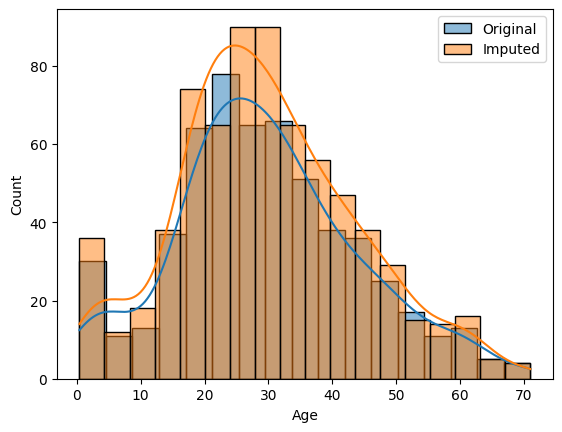

In [18]:
sns.histplot(X_train['Age'], label='Original', kde=True)
sns.histplot(X_train['Age_imputed'], label='Imputed', kde=True)

plt.legend()
plt.show()
